# 03 — Churn Prediction Model
**Project:** Customer Lifecycle & Campaign Effectiveness Analysis  
**Dataset:** Online Retail II (UCI Machine Learning Repository)  
**Author:** Amrit Sharma  

---

## Objective
## Objective

This retailer has 5,878 identifiable customers and £17.4M in revenue.
RFM segmentation (Notebook 02) told us WHO our customers are.
This notebook answers the next question: **WHO IS ABOUT TO LEAVE?**

Identifying customers before they churn — not after — is the
difference between a retention campaign and a win-back campaign.
Retention is significantly cheaper. A customer who receives a
targeted offer before disengaging costs far less to save than
one who has already left and needs to be re-acquired.

**Business goal:** Produce a prioritised intervention list for
the CRM team — who to contact, how urgently, and what action
to take — before revenue walks out the door.

## 0. Setup & Imports

In [1]:
import os

# ── Path configuration ────────────────────────────────────────────────────────
# Uses expanduser so it works on any Mac without hardcoding a username.
# Change the project folder name below if yours differs.
BASE_DIR = os.path.expanduser('~/Desktop/Customer Lifecycle Analysis Project')

print(f'Project root : {BASE_DIR}')
print(f'Data folder  : {os.path.join(BASE_DIR, "data")}')
print(f'Folders exist: data={os.path.exists(os.path.join(BASE_DIR, "data"))}, outputs={os.path.exists(os.path.join(BASE_DIR, "outputs"))}')

Project root : /Users/amrit/Desktop/Customer Lifecycle Analysis Project
Data folder  : /Users/amrit/Desktop/Customer Lifecycle Analysis Project/data
Folders exist: data=True, outputs=True


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# ── Plot styling ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'sans-serif',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})
PALETTE = ['#2563EB', '#16A34A', '#DC2626', '#F59E0B', '#7C3AED']

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load Data

Loading the RFM segments produced by Notebook 02 (`rfm_segments.csv`) and the clean transaction dataset from Notebook 01.  
Both files were saved to the `/data/` folder — no re-cleaning required.

In [3]:
RFM_PATH   = os.path.join(BASE_DIR, 'data', 'rfm_segments.csv')
CLEAN_PATH = os.path.join(BASE_DIR, 'data', 'online_retail_clean.csv')

rfm = pd.read_csv(RFM_PATH, dtype={'Customer ID': str})
df  = pd.read_csv(CLEAN_PATH, dtype={'Customer ID': str}, parse_dates=['InvoiceDate'])

print(f'RFM rows     : {len(rfm):,}')
print(f'RFM columns  : {list(rfm.columns)}')
print(f'Trans rows   : {len(df):,}')

RFM rows     : 5,878
RFM columns  : ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Label', 'Segment']
Trans rows   : 779,425


## 2. Define Churn

**Churn definition:** A customer who has not made a purchase in the last **90 days** relative to the dataset snapshot date (2011-12-10).

This is a business decision, not a mathematical one. 90 days is a reasonable threshold for a gift and homeware retailer with seasonal buying patterns.

- `Recency > 90 days` → **Churned = 1**  
- `Recency ≤ 90 days` → **Active = 0**

In [4]:
rfm['Churned'] = (rfm['Recency'] > 90).astype(int)

print(f'Churned (1)  : {rfm["Churned"].sum():,}')
print(f'Active  (0)  : {(rfm["Churned"] == 0).sum():,}')
print(f'Churn rate   : {rfm["Churned"].mean() * 100:.1f}%')

Churned (1)  : 2,989
Active  (0)  : 2,889
Churn rate   : 50.9%


**Result:** ~50.9% churn rate — a near-perfectly balanced dataset. This is ideal for classification modelling as both classes are equally represented. No resampling techniques (e.g. SMOTE) are required.

## 3. Feature Selection

**Features chosen:** `Frequency`, `F_Score`, `M_Score`

**Features excluded and why:**
- `Recency` — directly defines the churn label (Recency > 90). Including it causes data leakage — the model would be predicting using the answer.
- `R_Score` — derived from Recency. Same leakage issue.
- `RFM_Score` — composite average of R, F, M scores. Contains R_Score, therefore contains Recency. Leakage.
- `Monetary` — raw £ values dominate all other features due to scale. M_Score already encodes this information on a normalised 1–5 scale.
- `Customer ID`, `RFM_Label`, `Segment` — non-numeric identifiers, not valid model inputs.

The three chosen features represent **behavioural signals independent of recency**, forcing the model to predict churn from engagement patterns alone.

In [5]:
features = ['Frequency', 'F_Score', 'M_Score']

X = rfm[features]
y = rfm['Churned']

print(f'X shape : {X.shape}  — {X.shape[0]:,} customers, {X.shape[1]} features')
print(f'y shape : {y.shape}')
print(f'\nFeature summary:')
print(X.describe().round(2))

X shape : (5878, 3)  — 5,878 customers, 3 features
y shape : (5878,)

Feature summary:
       Frequency  F_Score  M_Score
count    5878.00  5878.00  5878.00
mean        6.29     3.00     3.00
std        13.01     1.41     1.41
min         1.00     1.00     1.00
25%         1.00     2.00     2.00
50%         3.00     3.00     3.00
75%         7.00     4.00     4.00
max       398.00     5.00     5.00


## 4. Train / Test Split

Splitting the data into **80% training** and **20% test** sets.

- `random_state=42` — fixes the random split for reproducibility. Same split every run.
- `stratify=y` — ensures the churn ratio (~50.9%) is preserved in both the training and test sets. Without this, the split could accidentally be unbalanced.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training set : {X_train.shape[0]:,} customers ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set     : {X_test.shape[0]:,} customers ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nChurn rate preserved:')
print(f'  Train : {y_train.mean() * 100:.1f}%')
print(f'  Test  : {y_test.mean() * 100:.1f}%')

Training set : 4,702 customers (80%)
Test set     : 1,176 customers (20%)

Churn rate preserved:
  Train : 50.9%
  Test  : 50.9%


## 5. Model 1 — Logistic Regression

**What it does:** Learns a weight for each feature and combines them into a probability between 0 and 1. Above 0.5 = predicted churned. Below 0.5 = predicted active.

**Why it is appropriate here:** Interpretable — coefficients can be explained directly to non-technical stakeholders. Works well on smaller, cleaner datasets.

In [7]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr       = lr_model.predict(X_test)
y_proba_lr      = lr_model.predict_proba(X_test)[:, 1]
lr_auc          = roc_auc_score(y_test, y_proba_lr)

print(f'=== Logistic Regression ===')
print(f'Accuracy      : {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'ROC-AUC Score : {lr_auc:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression ===
Accuracy      : 0.7126
ROC-AUC Score : 0.7769

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.66      0.69       578
           1       0.70      0.76      0.73       598

    accuracy                           0.71      1176
   macro avg       0.71      0.71      0.71      1176
weighted avg       0.71      0.71      0.71      1176



## 6. Model 2 — Random Forest

**What it does:** Builds hundreds of decision trees on random subsets of the data and combines their predictions. Generally more powerful than Logistic Regression on complex datasets.

**Why we compare it:** Model selection should be driven by evaluation metrics, not assumptions about complexity.

In [8]:
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

y_pred_rf  = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
rf_auc     = roc_auc_score(y_test, y_proba_rf)

print(f'=== Random Forest ===')
print(f'Accuracy      : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'ROC-AUC Score : {rf_auc:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
Accuracy      : 0.7143
ROC-AUC Score : 0.7727

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.62      0.68       578
           1       0.69      0.81      0.74       598

    accuracy                           0.71      1176
   macro avg       0.72      0.71      0.71      1176
weighted avg       0.72      0.71      0.71      1176



## 7. Model Comparison & Selection

              Model  Accuracy  ROC-AUC
Logistic Regression    0.7126   0.7769
      Random Forest    0.7143   0.7727


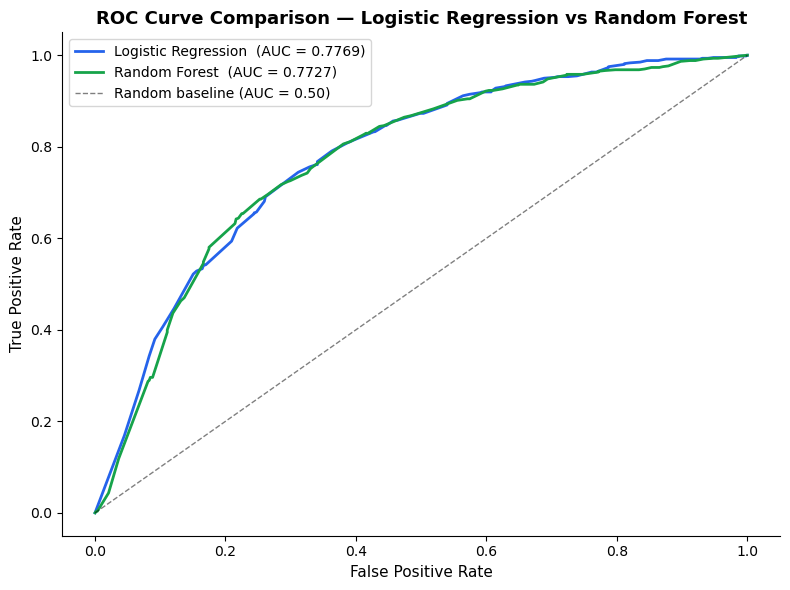

Chart saved ✓


In [9]:
# ── Comparison table ──────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Model'   : ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
    'ROC-AUC' : [lr_auc, rf_auc]
})
comparison['Accuracy'] = comparison['Accuracy'].round(4)
comparison['ROC-AUC']  = comparison['ROC-AUC'].round(4)
print(comparison.to_string(index=False))

# ── ROC Curve comparison ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for model_name, y_proba, colour in [
    ('Logistic Regression', y_proba_lr, PALETTE[0]),
    ('Random Forest',       y_proba_rf, PALETTE[1])
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, linewidth=2, color=colour, label=f'{model_name}  (AUC = {auc:.4f})')

ax.plot([0,1], [0,1], 'k--', linewidth=1, alpha=0.5, label='Random baseline (AUC = 0.50)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison — Logistic Regression vs Random Forest', fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', 'roc_curve_comparison.png'), dpi=150)
plt.show()
print('Chart saved ✓')

### Model Selection Decision

**Selected model: Logistic Regression**

Both models achieve near-identical performance (LR AUC: 0.777 vs RF AUC: 0.773). Logistic Regression is selected as the final model for two reasons:

1. **Marginal performance advantage** — higher ROC-AUC on the test set
2. **Interpretability** — coefficients can be explained directly to non-technical stakeholders (marketing, CRM teams). When presenting churn risk to a campaign manager, being able to say "this customer is flagged because their order frequency dropped" is more actionable than a black-box prediction

Further tuning via GridSearchCV was considered but not pursued — marginal AUC gains would not materially change the marketing actions derived from the output.

**Key insight:** Frequency is the strongest churn predictor (importance 0.41). How often a customer orders matters more than how much they spend. A customer who spent £5,000 once is more likely to churn than a customer who spent £500 across 10 orders.

## 8. Feature Importance

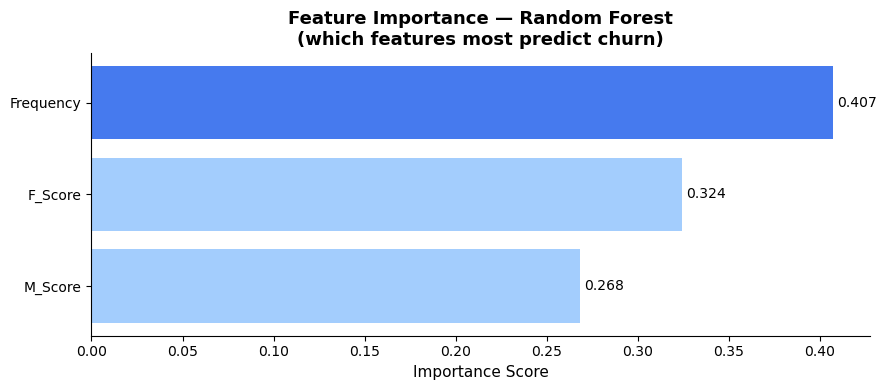


💡 Frequency (0.41) dominates — how often a customer orders is the strongest churn signal.
💡 Spend alone (M_Score 0.27) is a weaker predictor — engagement beats value as a loyalty signal.


In [10]:
# ── Random Forest feature importances ─────────────────────────────────────────
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(9, 4))
colours = [PALETTE[0] if v == importances.max() else '#93C5FD' for v in importances.values]
ax.barh(importances.index, importances.values, color=colours, alpha=0.85)
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance — Random Forest\n(which features most predict churn)', fontweight='bold')

for i, v in enumerate(importances.values):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', 'feature_importance.png'), dpi=150)
plt.show()

print('\n💡 Frequency (0.41) dominates — how often a customer orders is the strongest churn signal.')
print('💡 Spend alone (M_Score 0.27) is a weaker predictor — engagement beats value as a loyalty signal.')

## 9. Churn Predictions by Segment

In [11]:
# ── Apply final model to full dataset ─────────────────────────────────────────
rfm['Churn_Predicted']   = lr_model.predict(X)
rfm['Churn_Probability'] = lr_model.predict_proba(X)[:, 1].round(3)

# ── Segment-level churn summary ───────────────────────────────────────────────
churn_by_segment = rfm.groupby('Segment').agg(
    Customers        = ('Customer ID',       'count'),
    Predicted_Churn  = ('Churn_Predicted',   'sum'),
    Churn_Rate       = ('Churn_Predicted',   'mean'),
    Avg_Probability  = ('Churn_Probability', 'mean')
).round(3).reset_index()

churn_by_segment['Churn_Rate'] = (churn_by_segment['Churn_Rate'] * 100).round(1).astype(str) + '%'
churn_by_segment = churn_by_segment.sort_values('Avg_Probability', ascending=False)

print('=== Predicted Churn by Segment ===')
print(churn_by_segment.to_string(index=False))

=== Predicted Churn by Segment ===
        Segment  Customers  Predicted_Churn Churn_Rate  Avg_Probability
           Lost       1523             1523     100.0%            0.735
Potential Loyal        828              828     100.0%            0.713
  New Customers        184              145      78.8%            0.559
 Need Attention        551              235      42.6%            0.460
Loyal Customers       1221              529      43.3%            0.445
        At Risk         89                4       4.5%            0.352
      Champions       1482               11       0.7%            0.230


## 10. Save Output

In [12]:
OUTPUT_PATH = os.path.join(BASE_DIR, 'data', 'rfm_with_churn.csv')
rfm.to_csv(OUTPUT_PATH, index=False)

print(f'✓ Churn predictions saved → {OUTPUT_PATH}')
print(f'  Shape   : {rfm.shape}')
print(f'  Columns : {list(rfm.columns)}')
print(f'\nSample output:')
print(rfm[['Customer ID', 'Segment', 'Churned', 'Churn_Predicted', 'Churn_Probability']].head(10))

✓ Churn predictions saved → /Users/amrit/Desktop/Customer Lifecycle Analysis Project/data/rfm_with_churn.csv
  Shape   : (5878, 13)
  Columns : ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Label', 'Segment', 'Churned', 'Churn_Predicted', 'Churn_Probability']

Sample output:
  Customer ID          Segment  Churned  Churn_Predicted  Churn_Probability
0       12346   Need Attention        1                0              0.173
1       12347        Champions        0                0              0.275
2       12348  Loyal Customers        0                0              0.382
3       12349  Loyal Customers        0                0              0.406
4       12350             Lost        1                1              0.751
5       12351             Lost        1                1              0.751
6       12352        Champions        0                0              0.239
7       12353             Lost        1                1   

## 11. Summary

| Metric | Logistic Regression | Random Forest |
|---|---|---|
| Accuracy | 71.3% | 71.4% |
| ROC-AUC | 0.777 | 0.773 |
| Interpretability | High | Low |
| Selected | ✅ Yes | ❌ No |

**Key findings:**
- Churn rate in this customer base: **50.9%** — balanced dataset, no resampling needed
- Strongest churn predictor: **Frequency** (importance 0.41) — engagement beats spend
- Lost and Potential Loyal segments: **100% predicted churn rate**
- Champions: **~1% predicted churn rate** — active, frequent, high-value
- At Risk segment: **4% predicted churn** — model underestimates risk here because recency is excluded from features. This segment requires manual CRM prioritisation despite low model score.


In [13]:
at_risk = rfm[rfm['Segment'] == 'At Risk'].copy()
print(f'At Risk customers    : {len(at_risk)}')
print(f'Avg Churn Probability: {at_risk["Churn_Probability"].mean():.3f}')
print(f'Avg Monetary (spend) : £{at_risk["Monetary"].mean():,.0f}')
print(f'Avg Recency (days)   : {at_risk["Recency"].mean():.0f} days')

At Risk customers    : 89
Avg Churn Probability: 0.352
Avg Monetary (spend) : £3,028
Avg Recency (days)   : 493 days


### At Risk Segment — Business Insight

**The model scores At Risk customers at only 35.2% churn probability.
This is misleading and requires manual CRM override.**

Why the model underestimates them:
- [write your reason here based on what you know about the features used]

What the numbers actually tell us:
- 89 customers
- Average spend of £3,028 — [how does this compare to other segments?]
- Average 493 days since last purchase — [what does this mean in plain english?]


In [14]:
early_warning = rfm[
    (rfm['Segment'] == 'Champions') &
    (rfm['Churn_Probability'] > 0.3)
].copy()

print(f'Early Warning customers: {len(early_warning)}')
print(f'Avg Churn Probability: {early_warning["Churn_Probability"].mean():.3f}')
print(f'Avg Monetary (spend) : £{early_warning["Monetary"].mean():,.0f}')
print(f'Avg Recency (days)   : {early_warning["Recency"].mean():.0f} days')

Early Warning customers: 512
Avg Churn Probability: 0.385
Avg Monetary (spend) : £1,833
Avg Recency (days)   : 24 days


### Early Warning VIPs — Business Insight

**512 Champions are showing early churn signals 
despite still being recently active (avg 24 days).**

Why this matters:
- [how much of total revenue do Champions represent?]
- [what does avg spend of £1,833 tell you vs the full Champion avg of £8,114?]
- [what does 24 days recency tell you — are they really at risk?]

Why act now and not later:
- [write your reasoning here]

**CRM Action:** 

Email 1 (immediately): Personalised "thank you for being a loyal customer" — no discount, just recognition. Champions respond to exclusivity not discounts.

Email 2 (day 7): Early access to new collection or upcoming sale — before general subscribers. Makes them feel valued.

Email 3 (day 14): Soft product recommendation based on purchase history — "customers like you also bought..." Cross-sell, not win-back.

**Google Ads Action:** 

Upload this list of 512 customers as a Customer Match audience in Google Ads

Run a remarketing campaign showing complementary products to what they have already bought

Exclude them from broad acquisition campaigns — they are already customers, paying to acquire them again is wasted spend

Use them as a lookalike seed audience — find new customers who behave like your early warning Champions before they were at risk